<a href="https://colab.research.google.com/github/ibrahimshehin2017-sketch/WEBSITE-/blob/main/SVM%20FOR%20TURBULANCE%20DETECTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

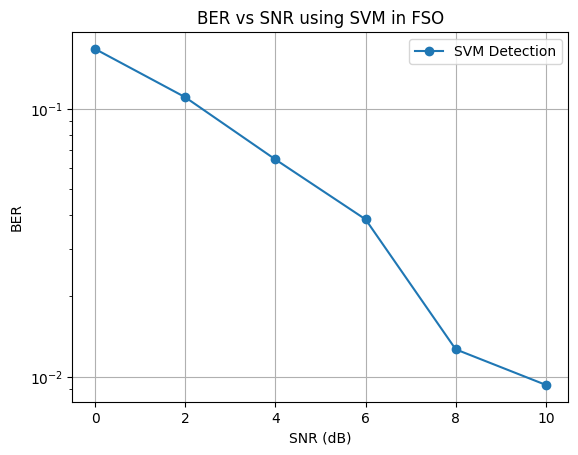

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Step 1: Generate binary data
N = 10000
data = np.random.randint(0, 2, N)

# Step 2: PAM Modulation (2-PAM: 0 -> -1, 1 -> +1)
tx_signal = 2*data - 1

# Step 3: Define SNR range
snr_db = np.arange(0, 11, 2)
ber_svm = []

for snr in snr_db:
    # Convert SNR to linear
    snr_linear = 10**(snr/10)

    # Step 4: Add noise (AWGN)
    noise = np.random.normal(0, 1/np.sqrt(snr_linear), N)

    # Step 5: Simulate turbulence (log-normal fading)
    sigma = 0.3
    turbulence = np.exp(sigma * np.random.randn(N))

    rx_signal = tx_signal * turbulence + noise

    # Reshape for ML model
    X = rx_signal.reshape(-1, 1)
    y = data

    # Step 6: Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

    # Step 7: Train SVM
    model = svm.SVC(kernel='rbf')
    model.fit(X_train, y_train)

    # Step 8: Predict
    y_pred = model.predict(X_test)

    # Step 9: Calculate BER
    ber = np.mean(y_pred != y_test)
    ber_svm.append(ber)

# Plot BER vs SNR
plt.figure()
plt.semilogy(snr_db, ber_svm, marker='o', label="SVM Detection")
plt.xlabel("SNR (dB)")
plt.ylabel("BER")
plt.title("BER vs SNR using SVM in FSO")
plt.grid()
plt.legend()
plt.show()